In [1]:
import sys
import os
import numpy as np
import pandas as pd

sys.path.append('c:/Users/User/Desktop/temp')

from __mypackage_py import *

## Обработка в Visit

In [6]:
wp = os.getcwd()
visit_wp = r'C:\Users\User\LLNL\VisIt3.5.0\visit.exe'
data_wp = r'C:\Users\User\Desktop\temp\cases\26-05__Backward_Facing_Step_multigrid\HC\att_1\run\out_grid3\silo\root\Backward_Facing_Step_grid_3_step_*.root'

result_wp = r'C:\Users\User\Desktop\temp\cases\26-05__Backward_Facing_Step_multigrid\HC\att_1\postproc\grid_3'
variables = ['/ALL/mesh', '/ALL/pressure', '/ALL/density']
extra_variables = {'velocity_magnitude': 'sqrt(<ALL/velocity_x>^2 + <ALL/velocity_y>^2 + <ALL/velocity_z>^2)'}
database = True



visit1 = visit_py()

visit1.creating_script_file(visit_wp=visit_wp,
                            data_wp=data_wp,
                            result_wp=result_wp,
                            script_wp=wp,
                            variables=variables, #/3D/FLUID
                            extra_variables=extra_variables,
                            database=database)

visit1.mass_flow_rate_convergence(c_min=0.001, c_max=33.7999)

for i in range(0, 53): #97
    visit1.time_set(i=i)
    file_name = 'X_5_' + str(i) + '.csv'

    visit1.lineout(X_data=[5, 5], Y_data=[0, 5], Z_data=[0, 0], num_points=100, result_file=file_name)

visit1.closing_visit_countdown(time=1)

In [12]:
wp = os.getcwd()
visit_wp = r'C:\Users\User\LLNL\VisIt3.5.0\visit.exe'
data_wp = r'C:\Users\User\Desktop\temp\cases\26-05__Backward_Facing_Step_multigrid\HC\att_1\run\out_grid3_multi\silo\root\Backward_Facing_Step_grid_3_step_*.root'

result_wp = r'C:\Users\User\Desktop\temp\cases\26-05__Backward_Facing_Step_multigrid\HC\att_1\postproc\grid_3_multi'
variables = ['/ALL/mesh', '/ALL/pressure', '/ALL/density']
extra_variables = {'velocity_magnitude': 'sqrt(<ALL/velocity_x>^2 + <ALL/velocity_y>^2 + <ALL/velocity_z>^2)'}
database = True



visit1 = visit_py()

visit1.creating_script_file(visit_wp=visit_wp,
                            data_wp=data_wp,
                            result_wp=result_wp,
                            script_wp=wp,
                            variables=variables, #/3D/FLUID
                            extra_variables=extra_variables,
                            database=database)

visit1.mass_flow_rate_convergence(c_min=0.001, c_max=33.7999)

for i in range(0, 23): #97
    visit1.time_set(i=i)
    file_name = 'X_5_' + str(i) + '.csv'

    visit1.lineout(X_data=[5, 5], Y_data=[0, 5], Z_data=[0, 0], num_points=100, result_file=file_name)

visit1.closing_visit_countdown(time=1)

In [13]:
visit1.launch(win_t_f=False)

In [14]:
wp = os.getcwd()

# col_names1 = ['x', 'y', 'z', 'p']


mfr_1_multi = pd.read_csv(os.path.join(wp, 'grid_1_multi', 'mass_flow_rate_convergence.csv'), sep=r'\s+') #, skiprows=1, names=col_names1
mfr_2_multi = pd.read_csv(os.path.join(wp, 'grid_2_multi', 'mass_flow_rate_convergence.csv'), sep=r'\s+')
mfr_3_multi = pd.read_csv(os.path.join(wp, 'grid_3_multi', 'mass_flow_rate_convergence.csv'), sep=r'\s+')
mfr_3 = pd.read_csv(os.path.join(wp, 'grid_3', 'mass_flow_rate_convergence.csv'), sep=r'\s+')

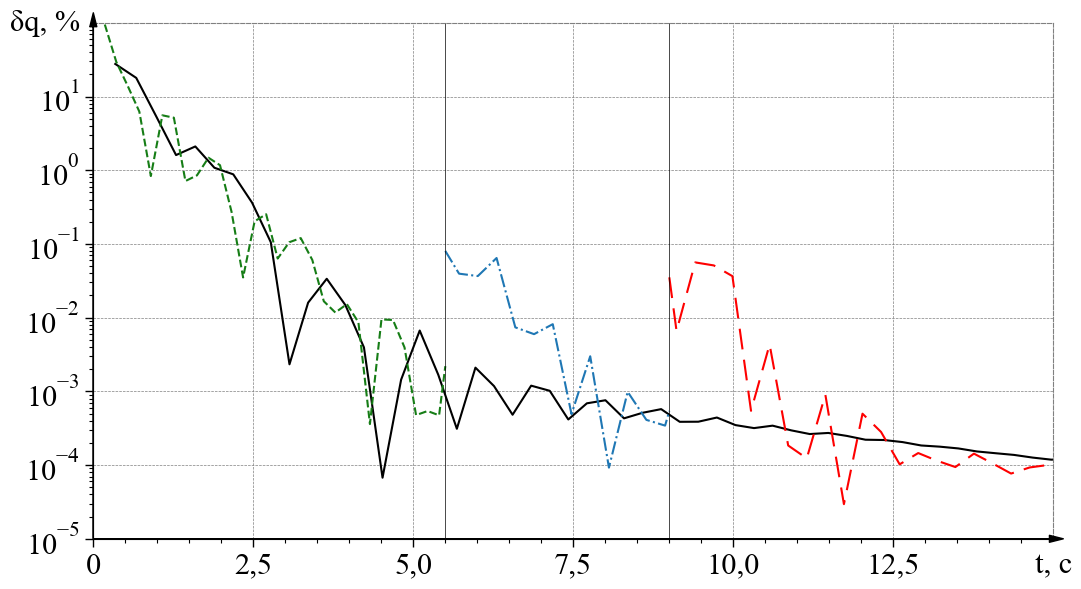

In [29]:
graph1 = GraphConfigurator(auto_range=False, XxYyZz_i_t_f=True, annot_t_f=False,
                        #    window_size_x=12.5, window_size_y=3,
                           y_scale='log',
                           Ox_lim=(0, 15), Ox_step=2.5,
                           Oy_lim=(1e-5, 1e2), Oy_step=10, 
                           x_label='t, с', y_label='δq, %',
                           precision_1=1, precision_2=0,
                        #    l_space=0.07, r_space=0.93,
                        #    b_space=0.15, t_space=0.95
                           )

graph1.conf_graph(*mfr_3.loc[1:, ['time', 'mfr']].values.T, line_width=1.5, line_type=0)
graph1.conf_graph(*mfr_1_multi.loc[1:, ['time', 'mfr']].values.T, line_width=1.5, line_type=1) #, col=0, line_type=0)
graph1.conf_graph(*mfr_2_multi.loc[:, ['time', 'mfr']].values.T, line_width=1.5, line_type=2)
graph1.conf_graph(*mfr_3_multi.loc[:, ['time', 'mfr']].values.T, line_width=1.5, line_type=4)

graph1.conf_graph([5.5, 5.5], [1e-5, 1e2], line_width=0.5, line_type=0, col=0)
graph1.conf_graph([9, 9], [1e-5, 1e2], line_width=0.5, line_type=0, col=0)

# graph1.conf_graph(*exp_top.loc[:, ['x', 'Cp']].values.T, mark_only_t_f=True, edge_col='black', col='white', mark_size=40)

## Графики

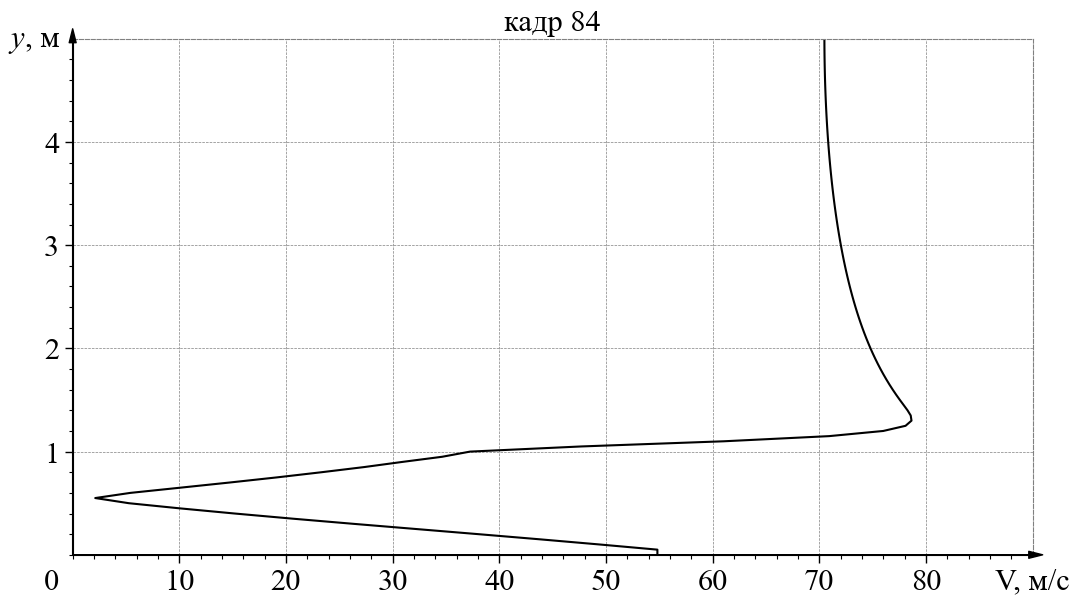

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import os
import glob


wp = os.path.join(os.getcwd(), 'grid_3')

X_5_1 = pd.read_csv(os.path.join(wp, 'X_5_1.csv'), sep=r'\s+')


graph1 = GraphConfigurator(auto_range=False, XxYyZz_i_t_f=True, annot_t_f=False,
                           Ox_lim=(0, 90), Ox_step=10,
                           Oy_lim=(0, 5), Oy_step=1, 
                           x_label='V, м/с', y_label='y, м',
                           precision_1=0, precision_2=0,
                           )

line1, = graph1.conf_graph(*X_5_1.loc[:, ['velocity_magnitude', 'y']].values.T, line_width=1.5)
# graph1.conf_title(title_lab='кадр 1', title_t_f=True)

def update_top(frame):
    file_name = 'X_5_' + str(frame + 1) + '.csv'
    X_5_1 = pd.read_csv(os.path.join(wp, file_name), sep=r'\s+')
    graph1.conf_title(title_lab=f'кадр {frame + 1}', title_t_f=True)
    # print(file_name)

    line1.set_ydata(X_5_1['y'].values)
    line1.set_xdata(X_5_1['velocity_magnitude'].values)
    return line1,



ani1 = FuncAnimation(graph1.fig, update_top, frames=4, interval=100, blit=True) #84



ani1.save('X_5_vel_grid_1.gif', writer='pillow', fps=5)

plt.show()

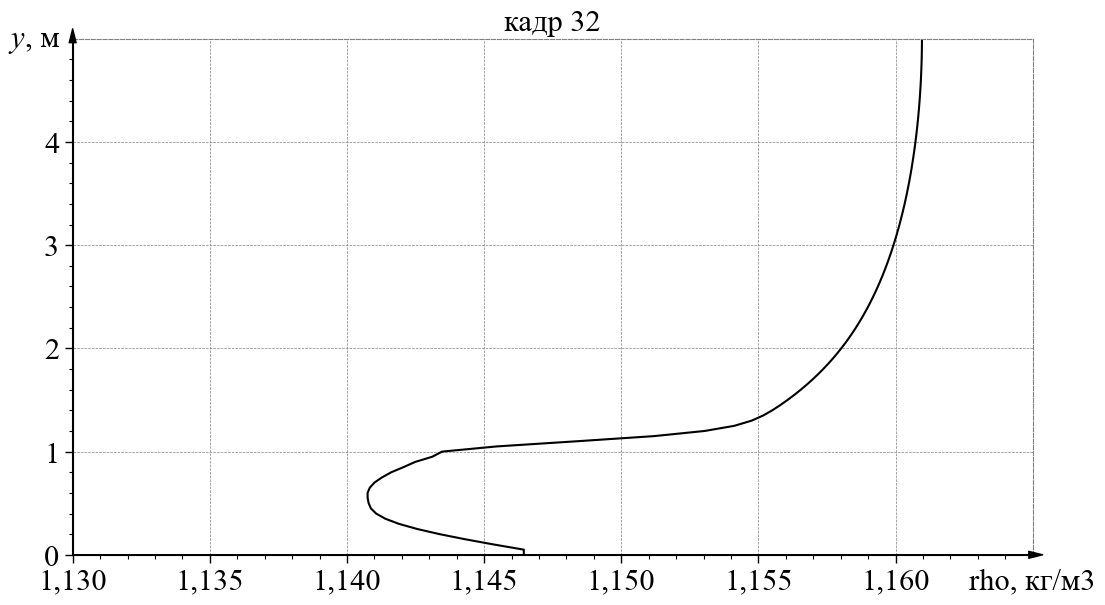

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import os
import glob


wp = os.path.join(os.getcwd(), 'grid_1_multi')

X_5_1 = pd.read_csv(os.path.join(wp, 'X_5_1.csv'), sep=r'\s+')


graph1 = GraphConfigurator(auto_range=False, XxYyZz_i_t_f=True, annot_t_f=False,
                           Ox_lim=(1.13, 1.165), Ox_step=0.005,
                           Oy_lim=(0, 5), Oy_step=1, 
                           x_label='rho, кг/м3', y_label='y, м',
                           precision_1=3, precision_2=0,
                           )

line1, = graph1.conf_graph(*X_5_1.loc[:, ['density', 'y']].values.T, line_width=1.5)
# graph1.conf_title(title_lab='кадр 1', title_t_f=True)

def update_top(frame):
    file_name = 'X_5_' + str(frame + 0) + '.csv'
    X_5_1 = pd.read_csv(os.path.join(wp, file_name), sep=r'\s+')
    graph1.conf_title(title_lab=f'кадр {frame + 1}', title_t_f=True)
    # print(file_name)

    line1.set_ydata(X_5_1['y'].values)
    line1.set_xdata(X_5_1['density'].values)
    return line1,



ani1 = FuncAnimation(graph1.fig, update_top, frames=32, interval=100, blit=True) #84



ani1.save('X_5_den_grid_1_multi.gif', writer='pillow', fps=3)

plt.show()

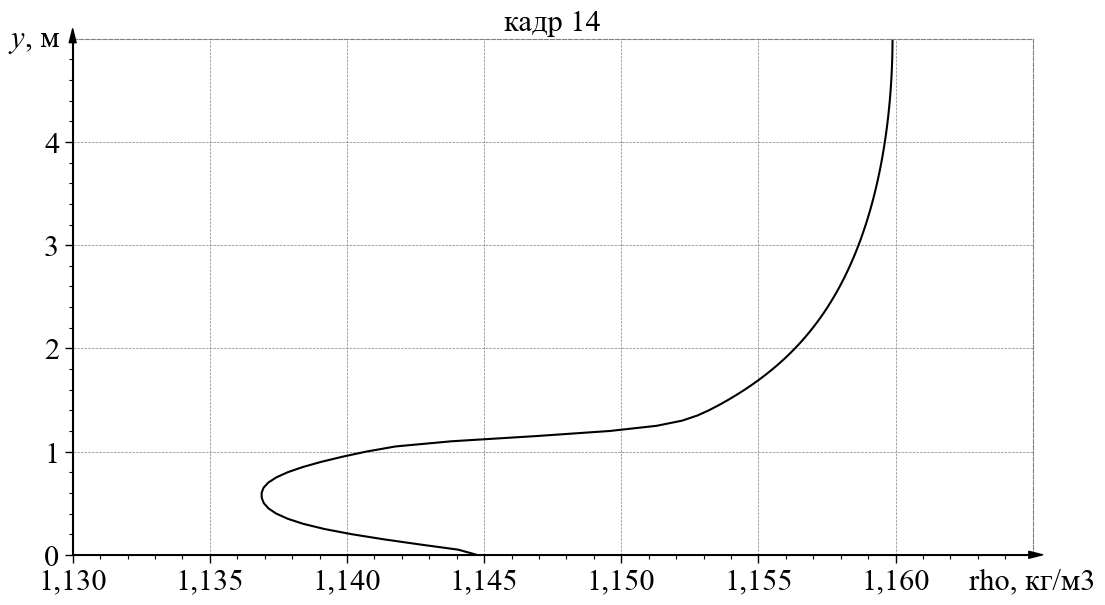

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import os
import glob


wp = os.path.join(os.getcwd(), 'grid_2_multi')

X_5_1 = pd.read_csv(os.path.join(wp, 'X_5_1.csv'), sep=r'\s+')


graph1 = GraphConfigurator(auto_range=False, XxYyZz_i_t_f=True, annot_t_f=False,
                           Ox_lim=(1.13, 1.165), Ox_step=0.005,
                           Oy_lim=(0, 5), Oy_step=1, 
                           x_label='rho, кг/м3', y_label='y, м',
                           precision_1=3, precision_2=0,
                           )

line1, = graph1.conf_graph(*X_5_1.loc[:, ['density', 'y']].values.T, line_width=1.5)
# graph1.conf_title(title_lab='кадр 1', title_t_f=True)

def update_top(frame):
    file_name = 'X_5_' + str(frame + 0) + '.csv'
    X_5_1 = pd.read_csv(os.path.join(wp, file_name), sep=r'\s+')
    graph1.conf_title(title_lab=f'кадр {frame + 1}', title_t_f=True)
    # print(file_name)

    line1.set_ydata(X_5_1['y'].values)
    line1.set_xdata(X_5_1['density'].values)
    return line1,



ani1 = FuncAnimation(graph1.fig, update_top, frames=14, interval=100, blit=True) #84



ani1.save('X_5_den_grid_2_multi.gif', writer='pillow', fps=3)

plt.show()

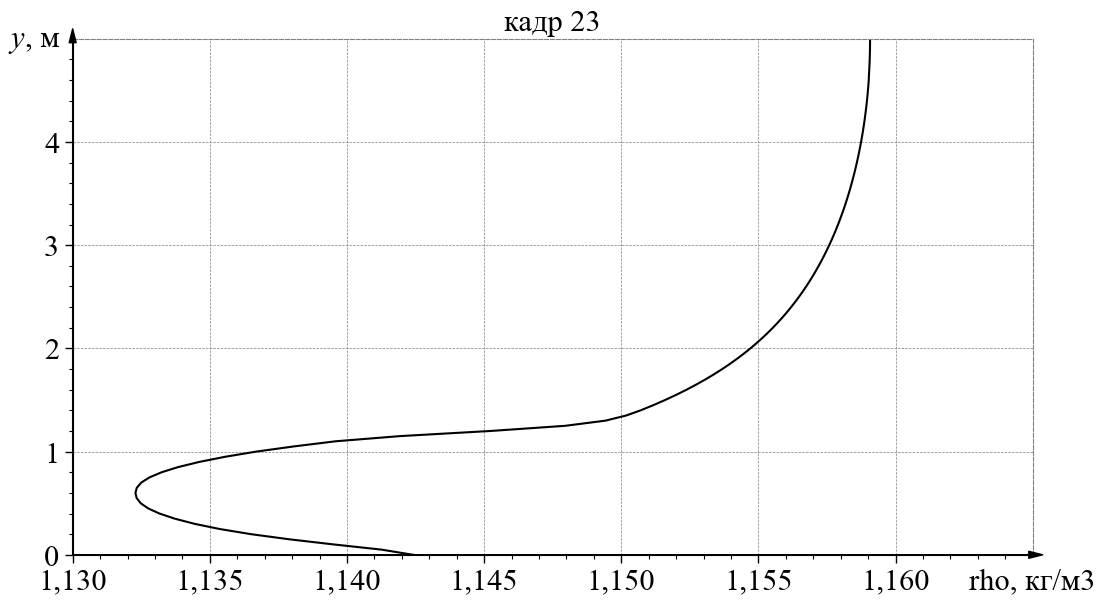

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import os
import glob


wp = os.path.join(os.getcwd(), 'grid_3_multi')

X_5_1 = pd.read_csv(os.path.join(wp, 'X_5_1.csv'), sep=r'\s+')


graph1 = GraphConfigurator(auto_range=False, XxYyZz_i_t_f=True, annot_t_f=False,
                           Ox_lim=(1.13, 1.165), Ox_step=0.005,
                           Oy_lim=(0, 5), Oy_step=1, 
                           x_label='rho, кг/м3', y_label='y, м',
                           precision_1=3, precision_2=0,
                           )

line1, = graph1.conf_graph(*X_5_1.loc[:, ['density', 'y']].values.T, line_width=1.5)
# graph1.conf_title(title_lab='кадр 1', title_t_f=True)

def update_top(frame):
    file_name = 'X_5_' + str(frame + 0) + '.csv'
    X_5_1 = pd.read_csv(os.path.join(wp, file_name), sep=r'\s+')
    graph1.conf_title(title_lab=f'кадр {frame + 1}', title_t_f=True)
    # print(file_name)

    line1.set_ydata(X_5_1['y'].values)
    line1.set_xdata(X_5_1['density'].values)
    return line1,



ani1 = FuncAnimation(graph1.fig, update_top, frames=23, interval=100, blit=True) #84



ani1.save('X_5_den_grid_3_multi.gif', writer='pillow', fps=3)

plt.show()

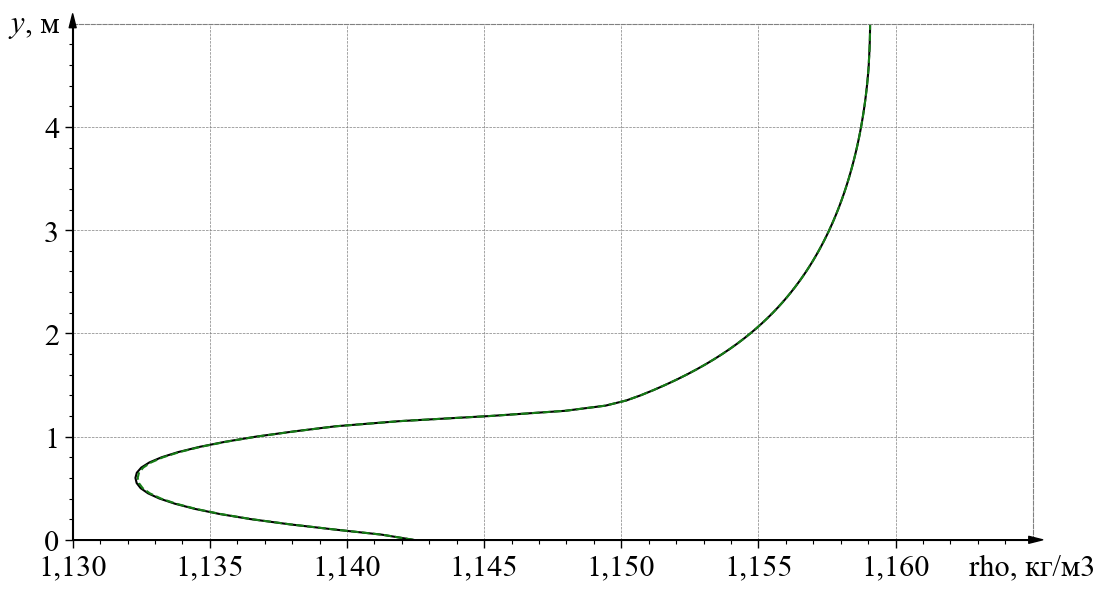

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import os
import glob


wp = os.path.join(os.getcwd(), 'grid_3_multi')

X_5_m = pd.read_csv(os.path.join(os.getcwd(), 'grid_3_multi', 'X_5_22.csv'), sep=r'\s+')
X_5 = pd.read_csv(os.path.join(os.getcwd(), 'grid_3', 'X_5_52.csv'), sep=r'\s+')


graph1 = GraphConfigurator(auto_range=False, XxYyZz_i_t_f=True, annot_t_f=False,
                           Ox_lim=(1.13, 1.165), Ox_step=0.005,
                           Oy_lim=(0, 5), Oy_step=1, 
                           x_label='rho, кг/м3', y_label='y, м',
                           precision_1=3, precision_2=0,
                           )

graph1.conf_graph(*X_5_m.loc[:, ['density', 'y']].values.T, line_width=1.5)
graph1.conf_graph(*X_5.loc[:, ['density', 'y']].values.T, line_width=1.5)

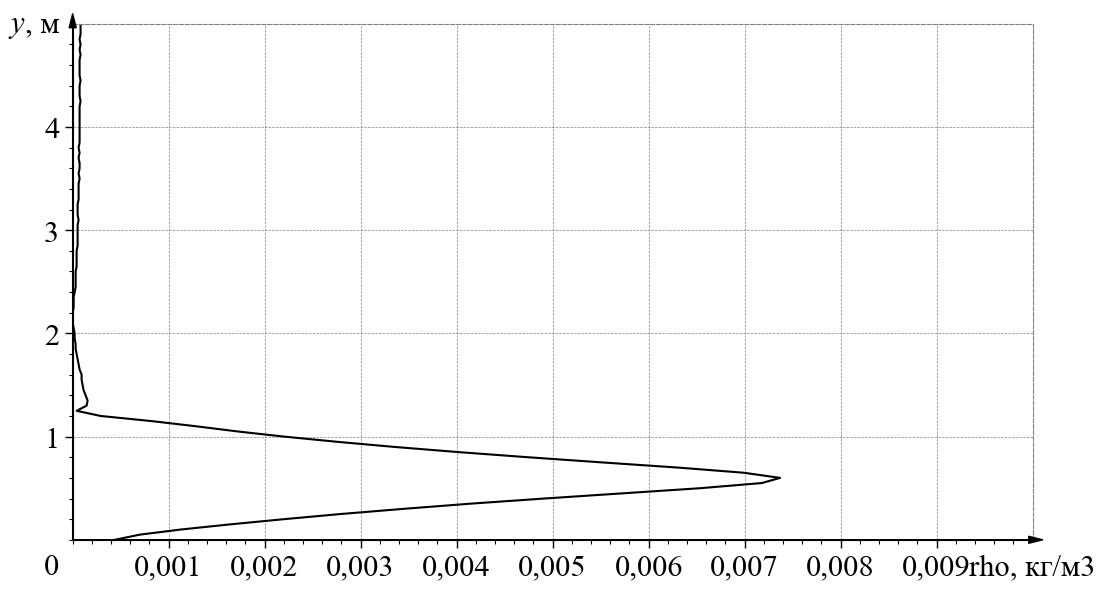

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import os
import glob


wp = os.path.join(os.getcwd(), 'grid_3_multi')

X_5_m = pd.read_csv(os.path.join(os.getcwd(), 'grid_3_multi', 'X_5_22.csv'), sep=r'\s+')
X_5 = pd.read_csv(os.path.join(os.getcwd(), 'grid_3', 'X_5_52.csv'), sep=r'\s+')

X_5['delta'] = abs(X_5_m['density'] - X_5['density']) / X_5['density'] * 100

graph1 = GraphConfigurator(auto_range=False, XxYyZz_i_t_f=True, annot_t_f=False,
                           Ox_lim=(0, 0.01), Ox_step=0.001,
                           Oy_lim=(0, 5), Oy_step=1, 
                           x_label='rho, кг/м3', y_label='y, м',
                           precision_1=3, precision_2=0,
                           )

graph1.conf_graph(*X_5.loc[:, ['delta', 'y']].values.T, line_width=1.5)

In [47]:
delta = round((1.17279 - 1.1317), 4)
delta

0.0411

In [65]:
m1_1 = pd.read_csv(os.path.join(os.getcwd(), 'grid_1_multi', 'X_5_29.csv'), sep=r'\s+')
m1_2 = pd.read_csv(os.path.join(os.getcwd(), 'grid_1_multi', 'X_5_30.csv'), sep=r'\s+')
delta_t = 0.18012
print(f'delta_den = {((abs(m1_2['density'] - m1_1['density']) / delta).max() * 100) / delta_t}, % / c')

delta_den = 1.9275270878117636, % / c


In [69]:
m2_1 = pd.read_csv(os.path.join(os.getcwd(), 'grid_2_multi', 'X_5_11.csv'), sep=r'\s+')
m2_2 = pd.read_csv(os.path.join(os.getcwd(), 'grid_2_multi', 'X_5_12.csv'), sep=r'\s+')
delta_t = 0.29247
print(f'delta_den = {((abs(m2_2['density'] - m2_1['density']) / delta).max() * 100) / delta_t}, % / c')

delta_den = 0.855850184166989, % / c


In [60]:
m3_1 = pd.read_csv(os.path.join(os.getcwd(), 'grid_3_multi', 'X_5_20.csv'), sep=r'\s+')
m3_2 = pd.read_csv(os.path.join(os.getcwd(), 'grid_3_multi', 'X_5_21.csv'), sep=r'\s+')
delta_t = 0.2902
print(f'delta_den = {((abs(m3_2['density'] - m3_1['density']) / delta).max() * 100) / delta_t}, % / c')

delta_den = 0.46375526192660566, % / c


In [59]:
b3_1 = pd.read_csv(os.path.join(os.getcwd(), 'grid_3', 'X_5_50.csv'), sep=r'\s+')
b3_2 = pd.read_csv(os.path.join(os.getcwd(), 'grid_3', 'X_5_51.csv'), sep=r'\s+')
delta_t = 0.2902
print(f'delta_den = {((abs(b3_2['density'] - b3_1['density']) / delta).max() * 100) / delta_t}, % / c')

delta_den = 0.5057331089113416, % / c


## Картинки сеток

In [ ]:
wp = os.getcwd()
visit_wp = r'C:\Users\User\LLNL\VisIt3.5.0\visit.exe'
data_wp = r'C:\Users\User\Desktop\temp\cases\26-05__Backward_Facing_Step_multigrid\HC\att_1\run\out_grid3_multi\silo\root\Backward_Facing_Step_grid_3_step_*.root'

result_wp = r'C:\Users\User\Desktop\temp\cases\26-05__Backward_Facing_Step_multigrid\HC\att_1\postproc\grid_3_multi'
variables = ['/ALL/mesh', '/ALL/pressure', '/ALL/density']
# extra_variables = {'velocity_magnitude': 'sqrt(<ALL/velocity_x>^2 + <ALL/velocity_y>^2 + <ALL/velocity_z>^2)'}
database = True



visit1 = visit_py()

visit1.creating_script_file(visit_wp=visit_wp,
                            data_wp=data_wp,
                            result_wp=result_wp,
                            script_wp=wp,
                            variables=variables, #/3D/FLUID
                            # extra_variables=extra_variables,
                            database=database)


visit1.pseudocolor_slice(norm=(0, 0, -1), 
                         point=(0.0, 0, 0),
                         geom_size=(0.12, 0.011), pixels=20000,
                         axis_t_f=False, legend_t_f = False, auto_minmax_t_f=True,
                         font_scale=1, #l_min=[300, 0.15, 1600], l_max=[3000, 0.3, 2000],
                         space=(0.1, 0.9, 0.1, 0.9))

visit1.closing_visit_countdown(time=1)

In [ ]:
visit1.launch(win_t_f=False)